# Solution 2.5: Loading, Inspecting and Cleaning (Angola IEA)

`IEA_2025_IV_TRIM_IND.sav`: the Inquerito ao Emprego em Angola, 4th quarter 2025,
published by INE Angola. 53,353 people, 206 columns, labels in Portuguese.

You will practice: reading the codebook to choose columns, loading with value
labels, recasting what the labels got wrong, and separating missing by design
from missing by error.

**PT:** `IEA_2025_IV_TRIM_IND.sav`: Inquerito ao Emprego em Angola, IV trimestre
2025, publicado pelo INE Angola. 53.353 pessoas, 206 colunas, etiquetas em
portugues.

Vai praticar: ler o dicionario de variaveis para escolher colunas, carregar com
etiquetas de valores, corrigir tipos que as etiquetas estragaram, e distinguir
valores em falta por desenho dos valores em falta por erro.

> **Pipeline:** reads `0_raw/`, writes `10_cleaned/`.

### Path Setup (run first)

Define the country folder once, then join sub folder and file name onto it.

**PT:** Defina a pasta do pais uma vez e depois junte a subpasta e o nome do
ficheiro.

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA_RAW_DIR = '../../data/0_raw/angola'
DATA_CLEAN_DIR = '../../data/10_cleaned'

EMPLOYMENT_DIR = 'employment_survey'
RAW_FILE = 'IEA_2025_IV_TRIM_IND.sav'
raw_path = os.path.join(DATA_RAW_DIR, EMPLOYMENT_DIR, RAW_FILE)

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
print('Data path:', raw_path)
print('Exists?:', os.path.exists(raw_path))

Data path: ../../data/0_raw/angola/employment_survey/IEA_2025_IV_TRIM_IND.sav
Exists?: True


---

## Task 1: Read the codebook before choosing columns

206 columns named `ATW_PAY` or `SRH_AVN` tell you nothing. The file carries a
description for every one of them, so read that first and let it drive the
selection.

`pd.read_spss` does not expose these descriptions, so this one cell uses
`pyreadstat` with `metadataonly=True`, which reads the header without loading
any data.

**PT:** 206 colunas com nomes como `ATW_PAY` nao dizem nada. O ficheiro traz uma
descricao de cada uma, entao leia isso primeiro e deixe a descricao guiar a
escolha. `pd.read_spss` nao da acesso a estas descricoes, por isso esta celula
usa `pyreadstat` com `metadataonly=True`, que le o cabecalho sem carregar dados.

In [2]:
import pyreadstat

_, meta = pyreadstat.read_sav(raw_path, metadataonly=True)
codebook = meta.column_names_to_labels

print('Variables described in the file:', len(codebook))
for name in ['PROV', 'DEM_AGE', 'ATW_PAY', 'SRH_AVN']:
    print(f'{name:12s} {codebook[name]}')

Variables described in the file: 206
PROV         G.01 Provincia
DEM_AGE      S02_03 Qual é a idade do(a) nome
ATW_PAY      S04_01 Nos últimos sete dias, o(a) nome trabalhou durante 1 ou mais horas, em alguma actividade por conta de outrem, com remuneração
SRH_AVN      S06_12 Se uma oportunidade de emprego ou negócio estivesse disponível, o(a) nome poderia ter começado a trabalhar nos últimos sete dias?


---

## Task 2: Find columns by what they measure

Search the descriptions instead of guessing at names. The number of matches is
itself informative: a precise concept returns one column, a vague one returns
twenty and forces you to choose.

**PT:** Pesquise nas descricoes em vez de adivinhar nomes. O numero de
resultados ja e informativo: um conceito preciso devolve uma coluna, um conceito
vago devolve vinte e obriga a escolher.

In [3]:
def find_columns(codebook, keyword):
    """Columns whose description contains `keyword`, case insensitive."""
    return {name: label for name, label in codebook.items()
            if label and keyword.lower() in label.lower()}


for keyword in ['sexo', 'idade', 'provincia', 'horas']:
    hits = find_columns(codebook, keyword)
    print(f'{keyword:12s} {len(hits):3d} matches')

sexo           1 matches
idade         22 matches
provincia      1 matches
horas         29 matches


In [4]:
# A vague keyword needs reading, not trusting
for name, label in find_columns(codebook, 'idade').items():
    print(f'{name:16s} {label[:70]}')

G_13             G.13 Número de Pessoas de 15+ anos de idade
S01_07           S01_05 O nome possui bilhete de identidade (BI)
DEM_AGE          S02_03 Qual é a idade do(a) nome
MIG_CTZ          S02_09 O(a) nome tem nacionalidade angolana
MIG_CTZ_CNTY     S02_10 Diga-me a nacionalidade do nome
DEM_TRN          S03_08 Além da escola, nas últimas 4 semanas, (você/nome) participou d
RSP_AVAIL        Disponibilidade do inquirido seleccionado para ser entrevistado
ATW_PAY          S04_01 Nos últimos sete dias, o(a) nome trabalhou durante 1 ou mais ho
ATW_PFT          S04_02 Nos últimos sete dias, o(a) nome trabalhou por conta própria, d
MJU_MAC          S05_12 Qual é a actividade principal do local onde o(a) nome exerce o 
MJU_PLC          S05_14 Em que local o(a) nome realiza a sua actividade principal?
MCD_CONMIN       S05_24 O contrato garante uma quantidade mínima de horas ou trabalho p
MJD_SINGLE_CLIENT S05_29 Mais da metade da receita do negócio/atividade vem de …?
MJD_SELL_CLIENT  S05_

**Answers:**

- `sexo` and `provincia` match exactly one column each. `idade` matches 22 and
  `horas` 29, because those words appear inside long question texts about other
  things.
- Reading the 22 `idade` matches shows only `DEM_AGE` is the respondent's own
  age. `G_13` counts household members aged 15 or more, which is a different
  variable entirely.
- Searching the codebook is a filter, not an oracle. It narrows 206 columns to a
  handful you then read properly.

---

## Task 3: Select the columns and keep their descriptions

Keep a `descriptions` dictionary alongside the data. Six months from now it is
the only thing that will tell you what `SRH_DES` meant.

**PT:** Guarde um dicionario `descriptions` junto com os dados. Daqui a seis
meses e a unica coisa que lhe dira o que significava `SRH_DES`.

In [5]:
SPSS_COLS = [
    'NIDF', 'PPNO', 'G_06_ID_IEA', 'PROV', 'AREA_RESID', 'G_15_TRIMESTRE',
    'DEM_REL', 'DEM_SEX', 'DEM_AGE', 'DEM_MRT', 'DEM_EDL', 'S03_01',
    'ATW_PAY', 'ATW_PFT', 'ATW_FAM', 'ABS_JOB',
    'SRH_JOB', 'SRH_BUS', 'SRH_AVN', 'SRH_AVL', 'SRH_DES',
    'WKT_USHRSTOT', 'WKT_ACHRSTOT', 'MJT_SYR', 'MJJ_EMP_REL', 'GHVEDT',
    'POND_IEA_IV_TRIM_2025_IND',
]

descriptions = {name.lower(): codebook[name] for name in SPSS_COLS}

print('Selected:', len(SPSS_COLS), 'of', len(codebook))
pd.Series(descriptions).str.slice(0, 80).to_frame('description')

Selected: 27 of 206


,description
nidf,None
ppno,Número da pessoa
g_06_id_iea,G.06 Número do Conglomerado (ID. IEA)
prov,G.01 Provincia
area_resid,G.05_Área de Residência
g_15_trimestre,G.15 Trimestre
dem_rel,S01_02 Qual é a relação de parentesco entre o(...
dem_sex,S02_01 Qual é o sexo do(a) nome
dem_age,S02_03 Qual é a idade do(a) nome
dem_mrt,S02_04 Qual é o estado civil do(a) nome


**Answers:**

- 27 of 206. `G_12` and `G_13` are deliberately absent: they are empty in every
  row of this extract, so there is no reason to load them.
- The keys are lower cased to match the column names after loading.
- The descriptions are the only defence against silently analysing the wrong
  variable, which is the most expensive mistake in survey work because nothing
  errors.

---

## Task 4: Load with value labels

Keep `convert_categoricals=True`, the default, so coded variables arrive as the
Portuguese labels stored in the file. Lower case the names: they are already
underscore separated, so that is enough to make them snake case, and nothing is
renamed, so every name still matches the codebook.

**PT:** Mantenha `convert_categoricals=True` para que as variaveis codificadas
cheguem com as etiquetas em portugues. Ponha os nomes em minusculas: nada e
renomeado, por isso cada nome continua a corresponder ao dicionario.

In [6]:
df = pd.read_spss(raw_path, usecols=SPSS_COLS, convert_categoricals=True)
df.columns = df.columns.str.lower()

print('Loaded:', df.shape)
df.head()

Loaded: (53353, 27)


,nidf,g_06_id_iea,prov,dem_rel,area_resid,g_15_trimestre,dem_sex,ppno,dem_age,dem_mrt,...,mjt_syr,wkt_ushrstot,wkt_achrstot,srh_job,srh_bus,srh_des,srh_avn,srh_avl,ghvedt,pond_iea_iv_trim_2025_ind
0,"9,250,068.00",925.00,Namibe,Cônjuge,Urbana,IVº Trimestre,Feminino,2.00,45.00,União de facto,...,"2,022.00",66.00,66.00,NaN,NaN,NaN,NaN,NaN,"20,251,204.00",322.02
1,"12,870,026.00","1,287.00",Cuando,Neto(a),Rural,IVº Trimestre,Masculino,9.00,7.00,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,171.30
2,"4,600,048.00",460.00,Cuanza-Sul,Filho (a),Rural,IVº Trimestre,Masculino,2.00,15.00,Solteiro/Nunca viveu em união de facto,...,NaN,NaN,NaN,Não,Não,Sim,Sim,NaN,"20,251,212.00","1,010.98"
3,"4,600,023.00",460.00,Cuanza-Sul,Chefe/Pessoa de referência,Rural,IVº Trimestre,Masculino,1.00,30.00,União de facto,...,NaN,NaN,NaN,Não,Não,Não,NaN,NaN,"20,251,212.00",999.80
4,"4,790,052.00",479.00,Cuanza-Sul,Chefe/Pessoa de referência,Rural,IVº Trimestre,Masculino,1.00,37.00,União de facto,...,"1,998.00",30.00,30.00,NaN,NaN,NaN,NaN,NaN,"20,251,216.00","1,011.64"


In [7]:
df.tail()

,nidf,g_06_id_iea,prov,dem_rel,area_resid,g_15_trimestre,dem_sex,ppno,dem_age,dem_mrt,...,mjt_syr,wkt_ushrstot,wkt_achrstot,srh_job,srh_bus,srh_des,srh_avn,srh_avl,ghvedt,pond_iea_iv_trim_2025_ind
53348,"10,740,010.00","1,074.00",Cunene,Chefe/Pessoa de referência,Rural,IVº Trimestre,Masculino,1.00,65.00,União de facto,...,"2,007.00",35.00,35.00,NaN,NaN,NaN,NaN,NaN,"20,251,122.00",485.25
53349,"10,740,010.00","1,074.00",Cunene,Outro parente,Rural,IVº Trimestre,Masculino,3.00,67.00,Separado(a),...,"2,025.00",4.00,4.00,NaN,NaN,NaN,NaN,NaN,"20,251,122.00",485.25
53350,"10,760,040.00","1,076.00",Cunene,Chefe/Pessoa de referência,Rural,IVº Trimestre,Masculino,1.00,65.00,União de facto,...,"1,990.00",5.00,5.00,NaN,NaN,NaN,NaN,NaN,"20,251,222.00",393.92
53351,"10,770,044.00","1,077.00",Cunene,Chefe/Pessoa de referência,Rural,IVº Trimestre,Masculino,1.00,69.00,União de facto,...,"1,990.00",8.00,8.00,NaN,NaN,NaN,NaN,NaN,"20,251,129.00",582.87
53352,"10,790,011.00","1,079.00",Cunene,Chefe/Pessoa de referência,Rural,IVº Trimestre,Masculino,1.00,72.00,União de facto,...,NaN,NaN,NaN,Não,Não,Não,NaN,NaN,"20,251,231.00",463.03


**Answers:**

- 53,353 rows and 27 columns, one row per person.
- `prov`, `area_resid` and `dem_sex` arrive as readable text (`Luanda`, `Urbana`,
  `Feminino`) rather than the numeric codes stored in the file.
- Keeping the questionnaire's own names means the `descriptions` dictionary from
  Task 3 still applies to every column.

---

## Task 5: Summary statistics

Look hard at every `min` and `max`, and at any `count` below 53,353.

**PT:** Olhe com atencao para cada `min` e `max`, e para qualquer `count`
abaixo de 53.353.

In [8]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
nidf,"53,353.00",NaN,NaN,NaN,"6,623,692.70","3,718,875.63","10,005.00","3,440,107.00","6,690,016.00","9,810,016.00","13,080,051.00"
g_06_id_iea,"53,353.00",NaN,NaN,NaN,662.36,371.89,1.00,344.00,669.00,981.00,"1,308.00"
prov,53353,21,Luanda,4424,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dem_rel,53352,11,Filho (a),27164,NaN,NaN,NaN,NaN,NaN,NaN,NaN
area_resid,53353,2,Urbana,34173,NaN,NaN,NaN,NaN,NaN,NaN,NaN
g_15_trimestre,53353,1,IVº Trimestre,53353,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dem_sex,53353,2,Feminino,27752,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ppno,"53,353.00",NaN,NaN,NaN,3.31,2.18,1.00,2.00,3.00,5.00,20.00
dem_age,"53,353.00",NaN,NaN,NaN,21.89,18.10,0.00,8.00,17.00,32.00,120.00
dem_mrt,32861,6,União de facto,13777,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Answers:**

- `wkt_ushrstot` and `wkt_achrstot` max out at 997. Nobody works 997 hours a
  week: that is a sentinel meaning "does not know".
- `dem_age` runs 0 to 120. Age 0 is legitimate, 1,532 infants. Age 120 is not.
- `ghvedt` has a mean around 20,251,000, nonsense as a number because it is
  really the date 2025-12-04 stored as the digits `20251204`.
- The `count` row exposes the skip pattern: the labour columns are answered by
  about a fifth of the sample.

---

## Task 6: Explore categories

`value_counts()` shows what is actually in a coded column. Always pass
`dropna=False`.

**PT:** `value_counts()` mostra o que esta realmente numa coluna codificada.
Use sempre `dropna=False`.

In [9]:
print(df['prov'].value_counts(dropna=False).sort_index())

prov
Bengo            2235
Benguela         2476
Bié              2422
Cabinda          2305
Cuando           1498
Cuanza-Norte     2676
Cuanza-Sul       2530
Cubango          2309
Cunene           2694
Huambo           2797
Huila            2837
Icolo e Bengo    2889
Luanda           4424
Lunda-Norte      2067
Lunda-Sul        2914
Malanje          2332
Moxico           1782
Moxico Leste     2123
Namibe           3108
Uíge             3029
Zaire            1906
Name: count, dtype: int64


In [10]:
print(df['area_resid'].value_counts(dropna=False))
print()
print(df['dem_sex'].value_counts(dropna=False))
print()
print('Distinct households:', df['nidf'].nunique())
print(df['nidf'].value_counts().describe())

area_resid
Urbana    34173
Rural     19180
Name: count, dtype: int64

dem_sex
Feminino     27752
Masculino    25601
Name: count, dtype: int64

Distinct households: 13036
count   13,036.00
mean         4.09
std          2.47
min          1.00
25%          2.00
50%          4.00
75%          6.00
max         20.00
Name: count, dtype: float64


**Answers:**

- All 21 provinces appear, Luanda largest at 4,424. Icolo e Bengo, Moxico Leste
  and Cuando were created in 2024, so any older reference table will not know
  them.
- 34,173 urban and 19,180 rural; 25,601 male and 27,752 female.
- 13,036 households across 53,353 people, a mean of 4.09 each.

---

## Task 7: Read the dtypes critically

The dtypes decide the next hour of work.

**PT:** Os tipos de dados determinam a proxima hora de trabalho.

In [11]:
print(type(df))
print(type(df['dem_age']))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>


In [12]:
df.dtypes

nidf                          float64
g_06_id_iea                   float64
prov                         category
dem_rel                      category
area_resid                   category
g_15_trimestre               category
dem_sex                      category
ppno                          float64
dem_age                       float64
dem_mrt                      category
s03_01                       category
dem_edl                      category
atw_pay                      category
atw_pft                      category
atw_fam                      category
abs_job                      category
mjj_emp_rel                  category
mjt_syr                      category
wkt_ushrstot                  float64
wkt_achrstot                  float64
srh_job                      category
srh_bus                      category
srh_des                      category
srh_avn                      category
srh_avl                      category
ghvedt                        float64
pond_iea_iv_

**Answers:**

- Labelled columns are `category`, the rest `float64`.
- Three are wrong for what the column means: `nidf`, `ppno` and `g_06_id_iea`
  are identifiers arriving as floats with a trailing `.0`; `ghvedt` is a date in
  a float; `mjt_syr` is a **year** that came back as `category`.

---

## Task 8: Recast what the file got wrong

`mjt_syr` is the year somebody started their main job. The value `9997` carries
the label `NAO SABE`, so pandas concluded the whole column is categorical, and a
year you cannot subtract is useless. `pd.to_numeric` with `errors='coerce'`
fixes it in one move: real years convert, the text label becomes `NaN`.

The hours columns carry the same `997` sentinel but no label for it, so they
stayed numeric and the sentinel has to be replaced by hand.

**PT:** `mjt_syr` e o ano em que a pessoa comecou o emprego principal. O valor
`9997` tem a etiqueta `NAO SABE`, por isso o pandas tornou a coluna categorica, e
um ano que nao se pode subtrair nao serve. `pd.to_numeric` com `errors='coerce'`
resolve: os anos reais convertem, a etiqueta vira `NaN`. As colunas de horas tem
o sentinela `997` sem etiqueta, por isso continuam numericas e o sentinela tem de
ser substituido a mao.

In [13]:
print('mjt_syr dtype before:', df['mjt_syr'].dtype)
print('non numeric categories:',
      [c for c in df['mjt_syr'].cat.categories if not isinstance(c, float)])

df['mjt_syr'] = pd.to_numeric(df['mjt_syr'].astype('object'), errors='coerce')

print()
print('mjt_syr dtype after: ', df['mjt_syr'].dtype)
print('range:', df['mjt_syr'].min(), 'to', df['mjt_syr'].max())
print('mean: ', round(df['mjt_syr'].mean(), 1))

mjt_syr dtype before: category
non numeric categories: ['NÃO SABE']

mjt_syr dtype after:  float64
range: 1965.0 to 2025.0
mean:  2017.4


In [14]:
print('hours max before:', df['wkt_ushrstot'].max())

df['wkt_ushrstot'] = df['wkt_ushrstot'].replace([997, 998, 999], np.nan)
df['wkt_achrstot'] = df['wkt_achrstot'].replace([997, 998, 999], np.nan)

print('hours max after: ', df['wkt_ushrstot'].max())

hours max before: 997.0
hours max after:  120.0


In [15]:
# Identifiers are labels, not quantities. Float to integer to string, or the
# trailing .0 survives and joins to nothing.
print('Before:', df['nidf'].head(3).tolist())

for col in ['nidf', 'ppno', 'g_06_id_iea']:
    df[col] = df[col].astype('int64').astype('string')

print('After: ', df['nidf'].head(3).tolist())

Before: [9250068.0, 12870026.0, 4600048.0]
After:  ['9250068', '12870026', '4600048']


In [16]:
# ghvedt is the float 20251204.0. Int64 tolerates the missing values.
df['ghvedt'] = pd.to_datetime(df['ghvedt'].astype('Int64').astype('string'),
                              format='%Y%m%d', errors='raise')

print('dtype:', df['ghvedt'].dtype)
print('Range:', df['ghvedt'].min(), 'to', df['ghvedt'].max())
print('Missing (NaT):', df['ghvedt'].isna().sum())
print()
print(df['ghvedt'].dt.month.value_counts(dropna=False).sort_index())

dtype: datetime64[ns]
Range: 2024-11-10 00:00:00 to 2026-01-28 00:00:00
Missing (NaT): 23671

ghvedt
1.00       553
11.00     9029
12.00    20100
NaN      23671
Name: count, dtype: int64


**Answers:**

- `mjt_syr` goes from `category` to `float64`, 1965 to 2025, mean 2017.4. The
  1,673 `NAO SABE` entries became `NaN`, which is the honest answer.
- `wkt_ushrstot` drops from 997 to 120 once the sentinel is replaced.
- Without the `int64` step the identifier reads `'9250068.0'` and matches nothing.
- The date range is **2024-11-10 to 2026-01-28**, both ends impossible for a 4th
  quarter file. 9,026 interviews fall in November 2025 and 20,100 in December,
  553 in January 2026 and 3 in November 2024. Not one is dated October, which for
  a quarter running October to December is worth raising with the producer.
- 23,671 rows have `NaT`, because the date is only recorded for labour module
  respondents.

---

## Task 9: Subset to inspect

Filtering here is for looking, not fixing.

**PT:** Aqui filtramos para observar, nao para corrigir.

In [17]:
print('wkt_ushrstot > 100:', (df['wkt_ushrstot'] > 100).sum())
df[df['wkt_ushrstot'] > 100][['nidf', 'wkt_ushrstot', 'wkt_achrstot']].head()

wkt_ushrstot > 100: 42


,nidf,wkt_ushrstot,wkt_achrstot
718,9580039,108.00,108.00
3304,6030115,105.00,105.00
3362,6100150,105.00,105.00
3441,6220127,105.00,105.00
5352,6680081,102.00,102.00


In [18]:
# Each condition needs its own parentheses
old_and_working = df[(df['dem_age'] >= 65) & (df['wkt_ushrstot'] > 40)]
print('People 65+ working over 40 hours:', len(old_and_working))

target = df[df['prov'].isin(['Luanda', 'Benguela'])]
print('Rows in Luanda or Benguela:', len(target))

People 65+ working over 40 hours: 140
Rows in Luanda or Benguela: 6900


**Answers:**

- 42 people report more than 100 usual hours a week, over 14 hours every day with
  no day off. The three 997 sentinels are already gone, so these are genuine.
- Parentheses are needed because `&` binds tighter than `>` in Python, so the
  unbracketed version parses in the wrong order and raises.

---

## Task 10: Detect missing values

Count them, express them as a share, and look at the shape before deciding.

**PT:** Conte, converta em percentagem, e observe o padrao antes de decidir.

In [19]:
missing = pd.DataFrame({
    'n_missing': df.isna().sum(),
    'pct_missing': (df.isna().mean() * 100).round(1),
})
missing.sort_values('pct_missing', ascending=False)

,n_missing,pct_missing
srh_avl,52539,98.50
mjt_syr,43389,81.30
srh_avn,43049,80.70
abs_job,42761,80.10
wkt_achrstot,41725,78.20
wkt_ushrstot,41719,78.20
mjj_emp_rel,41716,78.20
atw_fam,39090,73.30
srh_des,38305,71.80
srh_bus,37547,70.40


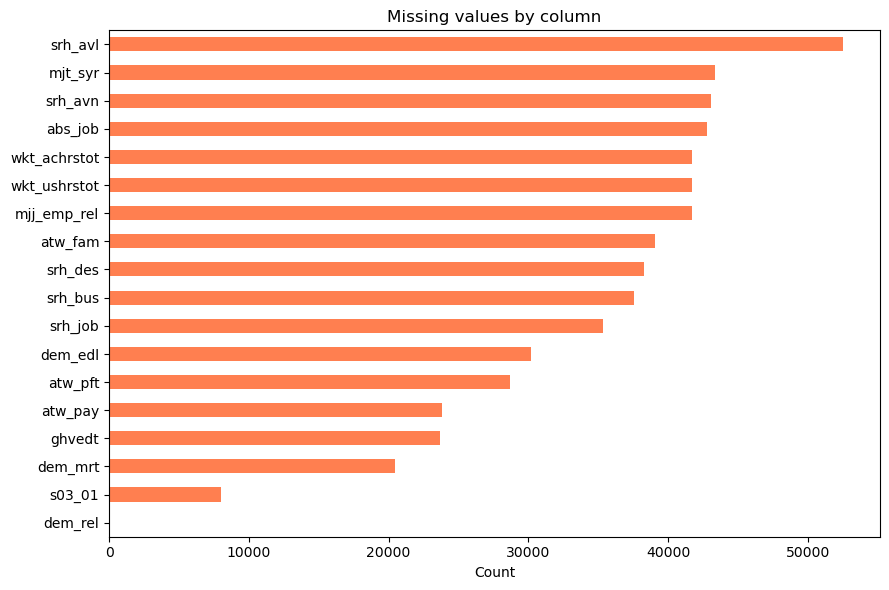

In [20]:
counts = df.isna().sum()
counts[counts > 0].sort_values().plot(kind='barh', color='coral', figsize=(9, 6))
plt.title('Missing values by column')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

**Answers:**

- A large block sits between 44% and 98.5% missing, and almost none of it is
  damage.
- The 78% group is the labour module: only people routed into it answer. The
  98.5% column is `srh_avl`, asked only of those who said no to `srh_avn`.
- Check the `descriptions` dictionary for any column you are unsure about. The
  question text usually explains the gap.

---

## Task 11: Missing by design is not missing by error

The textbook first move is `dropna()`. On a survey with skip patterns it is a
catastrophe. Measure it before you trust it.

**PT:** O primeiro reflexo e `dropna()`. Num inquerito com saltos de
questionario e uma catastrofe. Meca antes de confiar.

In [21]:
print('Rows now:                   ', len(df))
print('Rows if we called dropna(): ', len(df.dropna()))

Rows now:                    53353
Rows if we called dropna():  0


In [22]:
# Only the identifiers are non negotiable
print('Before:', df.shape)
df = df.dropna(subset=['nidf', 'ppno'])
print('After: ', df.shape)

Before: (53353, 27)


After:  (53353, 27)


**Answers:**

- `dropna()` leaves **0 rows**. Every person is missing at least one field,
  because nobody answers every module.
- Dropping on the identifiers removes nothing here, and is still worth running:
  it states the assumption and protects you on a dirtier extract.
- Filling the labour columns would be worse than leaving them empty. A person
  outside the labour force has no usual hours, and inventing a median would
  fabricate employment.

---

## Task 12: Duplicates on a compound key

No two rows are identical, so `duplicated()` alone finds nothing. The real key is
`nidf` plus `ppno`: one row per person per household.

**PT:** Nenhuma linha e identica a outra, por isso `duplicated()` sozinho nao
encontra nada. A chave real e `nidf` mais `ppno`.

In [23]:
print('Exact duplicate rows:', df.duplicated().sum())

dup_mask = df.duplicated(subset=['nidf', 'ppno'], keep=False)
print('Rows sharing a person key:', dup_mask.sum())
df[dup_mask].sort_values(['nidf', 'ppno'])[
    ['nidf', 'ppno', 'dem_age', 'dem_sex', 'dem_rel', 'wkt_ushrstot']]

Exact duplicate rows: 0
Rows sharing a person key: 16


,nidf,ppno,dem_age,dem_sex,dem_rel,wkt_ushrstot
13972,10820054,1,32.00,Masculino,Chefe/Pessoa de referência,66.00
13975,10820054,1,50.00,Masculino,Chefe/Pessoa de referência,60.00
19422,10820054,2,21.00,Feminino,Cônjuge,84.00
40360,10820054,2,39.00,Feminino,Cônjuge,NaN
2035,10820054,3,22.00,Masculino,Filho (a),NaN
30764,10820054,3,4.00,Feminino,Filho (a),NaN
2033,10820054,4,19.00,Masculino,Filho (a),NaN
37618,10820054,4,2.00,Masculino,Filho (a),NaN
16865,12890006,1,36.00,Masculino,Chefe/Pessoa de referência,NaN
17451,12890006,1,23.00,Masculino,Chefe/Pessoa de referência,NaN


In [24]:
# Keep the most complete record in each group
df['missing_count'] = df.isna().sum(axis=1)

print('Before:', df.shape)
df = (
    df
    .sort_values(['nidf', 'ppno', 'missing_count'])
    .drop_duplicates(subset=['nidf', 'ppno'], keep='first')
    .drop(columns='missing_count')
)
print('After: ', df.shape)

Before: (53353, 28)


After:  (53345, 27)


**Answers:**

- Zero exact duplicates, but **16 rows in 8 duplicate pairs**. Only the compound
  key finds them.
- 8 rows are removed, 53,353 down to 53,345.
- Look at the ages inside a group: household 10820054 has a person 1 aged 32 and
  another aged 50. These are two different people sharing an id, not one person
  entered twice, so "keep the most complete" is pragmatic and the real fix belongs
  with the data producer.

---

## Task 13: A rule that `describe()` cannot catch

Every household should have exactly one head. No summary statistic tells you
whether that holds, because it is a relationship between rows.

**PT:** Cada agregado deve ter exatamente um chefe. Nenhuma estatistica resumo
verifica isso, porque e uma relacao entre linhas.

In [25]:
heads = df[df['dem_rel'] == 'Chefe/Pessoa de referência']
heads_per_household = heads['nidf'].value_counts()

print('Households with two or more heads:', (heads_per_household > 1).sum())
print('Households with no head recorded: ',
      df['nidf'].nunique() - heads_per_household.index.nunique())

Households with two or more heads: 1
Households with no head recorded:  1


**Answers:**

- **1** household still has two heads, and **35** have none.
- Before Task 12 removed the duplicate person records, **6** households had two
  heads. Five were caused by the duplicates themselves, so deduplication fixed
  most of it. Run structural checks after cleaning, not before.

---

## Task 14: Save the cleaned dataset

Raw data is read only. Write to `10_cleaned/` and reload to confirm the round
trip.

**PT:** Os dados brutos sao apenas de leitura. Grave em `10_cleaned/` e recarregue
para confirmar.

In [26]:
os.makedirs(DATA_CLEAN_DIR, exist_ok=True)
out_path = os.path.join(DATA_CLEAN_DIR, 'angola_iea_2025q4_clean.csv')

df = df.reset_index(drop=True)
df.to_csv(out_path, index=False)
print('Saved:', out_path, '|', df.shape)

Saved: ../../data/10_cleaned/angola_iea_2025q4_clean.csv | (53345, 27)


In [27]:
check = pd.read_csv(out_path, dtype={'nidf': 'string', 'ppno': 'string',
                                     'g_06_id_iea': 'string'})
print('Reloaded:', check.shape)
print(check[['nidf', 'prov', 'ghvedt', 'mjt_syr']].dtypes)

Reloaded: (53345, 27)
nidf       string[python]
prov               object
ghvedt             object
mjt_syr           float64
dtype: object


**Answers:**

- **53,345 rows by 27 columns**, 8 fewer than loaded, every removal countable.
- `ghvedt` reloads as text and `prov` as text rather than `category`. CSV stores
  no dtypes, so every reader re-establishes them. The `descriptions` dictionary
  does not survive either, which is an argument for writing it alongside.
- `index=False` stops pandas writing row numbers as a nameless first column.